In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## TIEMPO vs Dimensiones

In [6]:
df_results=pd.read_csv('csv/resultados_dimensiones.csv')

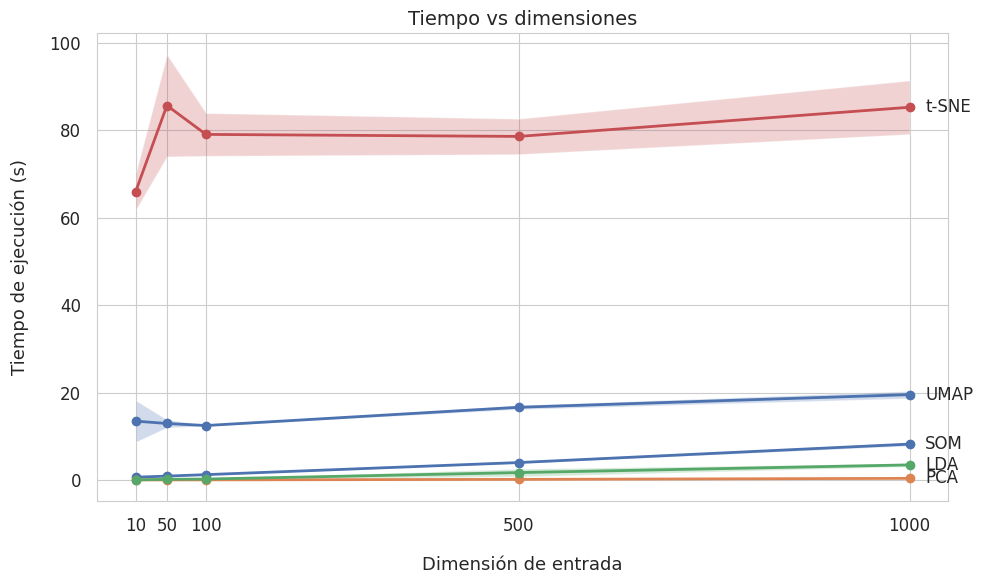

In [8]:

# --- Configuración de estilo ---
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

# --- Extraer datos de df_results ---
dims      = df_results['dims'].values
mean_som  = df_results['SOM_mean'].values
std_som   = df_results['SOM_std'].values
mean_pca  = df_results['PCA_mean'].values
std_pca   = df_results['PCA_std'].values
mean_lda  = df_results['LDA_mean'].values
std_lda   = df_results['LDA_std'].values
mean_tsne = df_results['t-SNE_mean'].values
std_tsne  = df_results['t-SNE_std'].values
mean_umap = df_results['UMAP_mean'].values
std_umap  = df_results['UMAP_std'].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

methods = [
    ('SOM',   mean_som,   std_som),
    ('PCA',   mean_pca,   std_pca),
    ('LDA',   mean_lda,   std_lda),
    ('t-SNE', mean_tsne,  std_tsne),
    ('UMAP',  mean_umap,  std_umap),
]

for label, mean_vals, std_vals in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    std_arr  = np.array(std_vals,  dtype=float)
    valid    = ~np.isnan(mean_arr)

    ax.plot(
        dims[valid],
        mean_arr[valid],
        marker='o',
        linewidth=2,
        label=label
    )
    ax.fill_between(
        dims[valid],
        mean_arr[valid] - std_arr[valid],
        mean_arr[valid] + std_arr[valid],
        alpha=0.25
    )

# Etiquetas directas al final de cada curva
for label, mean_vals, _ in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    valid_ix = np.where(~np.isnan(mean_arr))[0]
    if len(valid_ix) > 0:
        last_ix = valid_ix[-1]
        x, y = dims[last_ix], mean_arr[last_ix]
        ax.text(x * 1.02, y, label, va='center')

# Escalas y etiquetas
ax.set_xscale('linear')
ax.set_xticks(dims)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Dimensión de entrada')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title('Tiempo vs dimensiones')

plt.tight_layout()
plt.savefig("img/tiempo_vs_dimensiones.png",dpi=300)
plt.show()

## TIEMPO vs Muestras

In [ ]:
df_results=pd.read_csv('csv/resultados_muestras.csv')

In [ ]:

# --- Configuración de estilo ---
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

# --- Extraer datos de df_results ---
sample    = df_results['size'].values
mean_som  = df_results['SOM_mean'].values
std_som   = df_results['SOM_std'].values
mean_pca  = df_results['PCA_mean'].values
std_pca   = df_results['PCA_std'].values
mean_lda  = df_results['LDA_mean'].values
std_lda   = df_results['LDA_std'].values
mean_tsne = df_results['t-SNE_mean'].values
std_tsne  = df_results['t-SNE_std'].values
mean_umap = df_results['UMAP_mean'].values
std_umap  = df_results['UMAP_std'].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

methods = [
    ('SOM',   mean_som,   std_som),
    ('PCA',   mean_pca,   std_pca),
    ('LDA',   mean_lda,   std_lda),
    ('t-SNE', mean_tsne,  std_tsne),
    ('UMAP',  mean_umap,  std_umap),
]

for label, mean_vals, std_vals in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    std_arr  = np.array(std_vals,  dtype=float)
    valid    = ~np.isnan(mean_arr)

    ax.plot(
        sample[valid],
        mean_arr[valid],
        marker='o',
        linewidth=2,
        label=label
    )
    ax.fill_between(
        sample[valid],
        mean_arr[valid] - std_arr[valid],
        mean_arr[valid] + std_arr[valid],
        alpha=0.25
    )

# Etiquetas directas al final de cada curva
for label, mean_vals, _ in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    valid_ix = np.where(~np.isnan(mean_arr))[0]
    if len(valid_ix) > 0:
        last_ix = valid_ix[-1]
        x, y = sample[last_ix], mean_arr[last_ix]
        ax.text(x * 1.02, y, label, va='center')

# Escalas y etiquetas
ax.set_xscale('linear')
ax.set_xticks(sample)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Número de muestras utilizadas')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title('Tiempo vs muestras')

plt.tight_layout()
plt.savefig("img/tiempo_vs_muestras_.png",dpi=300)
plt.show()